### Python-control を使った倒立振り子の制御設計とシミュレーション

倒立振り子の物理モデル：

  - カートが水平方向に移動
  - 振り子が上に立っている不安定なシステム
  - 目的：カートの位置を制御しながら、振り子を立てたままに保つ

#### 【倒立振り子の制御問題】
  
  物理システム:

    - 不安定なシステム（開ループでは倒れてしまう）
    - 非線形なダイナミクス
    - カート位置と振り子角度を同時に制御
  
  状態空間表現:
  
    - 4つの状態: [カート位置, カート速度, 振り子角度, 振り子角速度]
    - 1つの入力: カートへの力
    - 4つの出力: すべての状態


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import odeint
import control as ctrl

In [2]:
print("\n" + "=" * 80)
print("Python-control による倒立振り子の制御設計")
print("=" * 80)

# ========== システムパラメータ ==========
print("\n【システムパラメータ】")
print("-" * 80)

# 物理パラメータ
M = 1.0      # カートの質量 [kg]
m = 0.1      # 振り子の質量 [kg]
L = 0.5      # 振り子の長さ [m]
g = 9.81     # 重力加速度 [m/s^2]
b = 0.1      # 摩擦係数 [N·s/m]

print(f"カートの質量 (M): {M} kg")
print(f"振り子の質量 (m): {m} kg")
print(f"振り子の長さ (L): {L} m")
print(f"重力加速度 (g): {g} m/s²")
print(f"摩擦係数 (b): {b} N·s/m")


Python-control による倒立振り子の制御設計

【システムパラメータ】
--------------------------------------------------------------------------------
カートの質量 (M): 1.0 kg
振り子の質量 (m): 0.1 kg
振り子の長さ (L): 0.5 m
重力加速度 (g): 9.81 m/s²
摩擦係数 (b): 0.1 N·s/m


In [3]:
# ========== 状態空間モデルの構築 ==========
print("\n【状態空間モデルの構築】")
print("-" * 80)

# 状態変数: x = [x_pos, x_vel, theta, theta_vel]^T
# x_pos: カートの位置
# x_vel: カートの速度
# theta: 振り子の角度（上向き=0）
# theta_vel: 振り子の角速度

# 倒立振り子の線形化されたダイナミクス
# https://en.wikipedia.org/wiki/Inverted_pendulum

# 計算中間値
I = m * L**2  # 振り子の慣性モーメント
mu = b + m * L**2 / L  # 係数

# 状態空間マトリックス
A = np.array([
    [0, 1, 0, 0],
    [0, -(b * (M + m)) / (M * m * L), m**2 * g * L / (M * m * L), 0],
    [0, 0, 0, 1],
    [0, -(b * L) / (I * (M + m) / (M * L)), m * g * (M + m) * L / (I * (M + m) / (M * L)), 0]
])

# より簡潔な定義
denom = (M + m) * (4 / 3 * L) - m * L
A = np.array([
    [0, 1, 0, 0],
    [0, -b / (M + m), m * g / (M + m), 0],
    [0, 0, 0, 1],
    [0, -b * L / (I * (M + m)), (M + m) * g * L / (I * (M + m)), 0]
])

B = np.array([
    [0],
    [1 / (M + m)],
    [0],
    [L / (I * (M + m))]
])

C = np.eye(4)  # すべての状態を出力
D = np.zeros((4, 1))

# システムを作成
sys = ctrl.StateSpace(A, B, C, D)

print("状態空間表現:")
print(f"状態 x = [x_pos, x_vel, θ, θ_vel]^T")
print(f"入力 u = カートへの力 [N]")
print(f"出力 y = すべての状態")
print(f"\nA マトリックス (4×4):")
print(A)
print(f"\nB ベクトル (4×1):")
print(B)



【状態空間モデルの構築】
--------------------------------------------------------------------------------
状態空間表現:
状態 x = [x_pos, x_vel, θ, θ_vel]^T
入力 u = カートへの力 [N]
出力 y = すべての状態

A マトリックス (4×4):
[[ 0.00000000e+00  1.00000000e+00  0.00000000e+00  0.00000000e+00]
 [ 0.00000000e+00 -9.09090909e-02  8.91818182e-01  0.00000000e+00]
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00  1.00000000e+00]
 [ 0.00000000e+00 -1.81818182e+00  1.96200000e+02  0.00000000e+00]]

B ベクトル (4×1):
[[ 0.        ]
 [ 0.90909091]
 [ 0.        ]
 [18.18181818]]


In [4]:
# ========== システムの特性解析 ==========
print("\n【開ループシステムの安定性分析】")
print("-" * 80)

# 極（固有値）を計算
poles = np.linalg.eigvals(A)
print(f"\\nシステムの極:")
for i, pole in enumerate(poles):
    if np.abs(pole.imag) < 1e-6:
        print(f"  λ{i+1} = {pole.real:.4f} (実数)")
    else:
        print(f"  λ{i+1} = {pole.real:.4f} ± j{np.abs(pole.imag):.4f}")

# 安定性判定
if np.all(np.real(poles) < 0):
    print("\n✓ システムは安定です")
else:
    print("\n✗ システムは不安定です（制御が必要）")

# 可制御性を確認
W_c = ctrl.ctrb(A, B)  # 可制御行列
rank_Wc = np.linalg.matrix_rank(W_c)
print(f"\n可制御性:")
print(f"  可制御行列の階数: {rank_Wc} / {A.shape[0]}")
if rank_Wc == A.shape[0]:
    print(f"  ✓ システムは完全可制御です")
else:
    print(f"  ✗ システムは不完全可制御です")


【開ループシステムの安定性分析】
--------------------------------------------------------------------------------
\nシステムの極:
  λ1 = 0.0000 (実数)
  λ2 = -0.0826 (実数)
  λ3 = -14.0113 (実数)
  λ4 = 14.0030 (実数)

✗ システムは不安定です（制御が必要）

可制御性:
  可制御行列の階数: 4 / 4
  ✓ システムは完全可制御です


#### 【制御設計手法】
  
  1. 極配置法（Pole Placement）
     - 線形化システムで閉ループ極を指定
     - ctrl.place() を使用
     - 高速な応答が得られる
  
  2. LQR (Linear Quadratic Regulator)
     - 二次型コスト関数を最小化
     - 状態と入力の重み付けを設定
     - 最適なゲインを計算
     - より実現的でロバストな制御

In [5]:
# ========== フィードバック制御器設計 (状態フィードバック) ==========
print("\n【状態フィードバック制御器設計】")
print("-" * 80)

# 目標の極（望ましい閉ループ極の場所）
pole_desired = np.array([-1.0, -1.5, -2.0, -2.5])

# 極配置法（Pole Placement）で制御器を設計
K = ctrl.place(A, B, pole_desired)

print(f"\n目標の極: {pole_desired}")
print(f"\nフィードバックゲイン K:")
print(K)
print(f"\nK = [{K[0,0]:.4f}, {K[0,1]:.4f}, {K[0,2]:.4f}, {K[0,3]:.4f}]")



【状態フィードバック制御器設計】
--------------------------------------------------------------------------------

目標の極: [-1.  -1.5 -2.  -2.5]

フィードバックゲイン K:
[[-0.04625382 -0.21871814 11.76956269  0.39093591]]

K = [-0.0463, -0.2187, 11.7696, 0.3909]


In [6]:
# 閉ループシステムを作成
A_cl = A - B @ K  # 閉ループA行列
sys_cl = ctrl.StateSpace(A_cl, B, C, D)

# 閉ループの極を確認
poles_cl = np.linalg.eigvals(A_cl)
print(f"\\n閉ループシステムの極:")
for i, pole in enumerate(poles_cl):
    if np.abs(pole.imag) < 1e-6:
        print(f"  λ{i+1} = {pole.real:.4f}")
    else:
        print(f"  λ{i+1} = {pole.real:.4f} ± j{np.abs(pole.imag):.4f}")


\n閉ループシステムの極:
  λ1 = -2.5000
  λ2 = -2.0000
  λ3 = -1.5000
  λ4 = -1.0000


In [7]:
# ========== Luenberger オブザーバーの設計 ==========
print("\n【観測器（オブザーバー）の設計】")
print("-" * 80)

# 観測器の極（制御器より速い応答）
pole_observer = np.array([-3.0, -3.5, -4.0, -4.5])

#観測器ゲインを設計
L = ctrl.place(A.T, C.T, pole_observer).T

print(f"観測器の目標極: {pole_observer}")
print(f"\n観測器ゲイン L (4×4):")
print(L)


【観測器（オブザーバー）の設計】
--------------------------------------------------------------------------------
観測器の目標極: [-3.  -3.5 -4.  -4.5]

観測器ゲイン L (4×4):
[[  4.5          1.          -0.          -0.        ]
 [ -0.           3.90909091   0.89181818  -0.        ]
 [ -0.          -0.           3.5          1.        ]
 [ -0.          -1.81818182 196.2          3.        ]]


In [8]:
# ========== LQR (Linear Quadratic Regulator) 設計 ==========
print("\n【LQR制御器設計】")
print("-" * 80)

# 重み行列（コスト関数最小化）
Q = np.diag([100, 1, 100, 1])  # 状態の重み（位置と角度を重視）
R = np.array([[1]])             # 入力の重み

K_lqr, S, E = ctrl.lqr(A, B, Q, R)

print(f"\nQ マトリックス (状態の重み):")
print(Q)
print(f"\nR (入力の重み): {R[0,0]}")

print(f"\nLQR フィードバックゲイン:")
print(K_lqr)

# 閉ループシステム（LQR）
A_cl_lqr = A - B @ K_lqr
sys_cl_lqr = ctrl.StateSpace(A_cl_lqr, B, C, D)



【LQR制御器設計】
--------------------------------------------------------------------------------

Q マトリックス (状態の重み):
[[100   0   0   0]
 [  0   1   0   0]
 [  0   0 100   0]
 [  0   0   0   1]]

R (入力の重み): 1

LQR フィードバックゲイン:
[[-10.          -7.2674845   33.24824555   2.50426146]]


In [9]:
poles_lqr = np.linalg.eigvals(A_cl_lqr)
print(f"\\nLQRによる閉ループの極:")
for i, pole in enumerate(poles_lqr):
    if np.abs(pole.imag) < 1e-6:
        print(f"  λ{i+1} = {pole.real:.4f}")
    else:
        print(f"  λ{i+1} = {pole.real:.4f} ± j{np.abs(pole.imag):.4f}")


\nLQRによる閉ループの極:
  λ1 = -24.5982
  λ2 = -10.8780
  λ3 = -1.7700 ± j1.7109
  λ4 = -1.7700 ± j1.7109


In [10]:
# ========== 非線形シミュレーション ==========
print("\n【非線形シミュレーション】")
print("-" * 80)

# 非線形システムの微分方程式 - 簡略化版
# 線形化システムを使用（実装が簡単で安定）

# 初期条件（振り子が少し傾いている状態）
x0 = np.array([0.0, 0.0, 0.1, 0.0])  # 10度の初期角度

# シミュレーション時間
t = np.linspace(0, 10, 1000)


【非線形シミュレーション】
--------------------------------------------------------------------------------


In [11]:
# LQR制御での閉ループシステムシミュレーション
# x' = (A - BK)x
A_cl_lqr_sim = A - B @ K_lqr
x_lqr = np.zeros((len(t), 4))
x_lqr[0] = x0

for i in range(len(t)-1):
    dt = t[i+1] - t[i]
    # 前進オイラー法で線形システムを積分
    x_lqr[i+1] = x_lqr[i] + A_cl_lqr_sim @ x_lqr[i] * dt

print(f"\n初期条件: x = {x0}")
print(f"シミュレーション時間: 0 ~ {t[-1]} 秒")
print(f"ステップ数: {len(t)}")

# 結果からの最大値・最小値
print(f"\n【シミュレーション結果（LQR制御）】")
print(f"カート位置 x_pos:")
print(f"  最小値: {x_lqr[:, 0].min():.4f} m")
print(f"  最大値: {x_lqr[:, 0].max():.4f} m")
print(f"  最終値: {x_lqr[-1, 0]:.6f} m")

print(f"\n振り子角度 θ:")
print(f"  最小値: {x_lqr[:, 2].min():.6f} rad = {np.degrees(x_lqr[:, 2].min()):.4f}°")
print(f"  最大値: {x_lqr[:, 2].max():.6f} rad = {np.degrees(x_lqr[:, 2].max()):.4f}°")
print(f"  最終値: {x_lqr[-1, 2]:.6f} rad = {np.degrees(x_lqr[-1, 2]):.4f}°")



初期条件: x = [0.  0.  0.1 0. ]
シミュレーション時間: 0 ~ 10.0 秒
ステップ数: 1000

【シミュレーション結果（LQR制御）】
カート位置 x_pos:
  最小値: -0.0278 m
  最大値: 0.0011 m
  最終値: 0.000000 m

振り子角度 θ:
  最小値: -0.027163 rad = -1.5563°
  最大値: 0.100000 rad = 5.7296°
  最終値: -0.000000 rad = -0.0000°


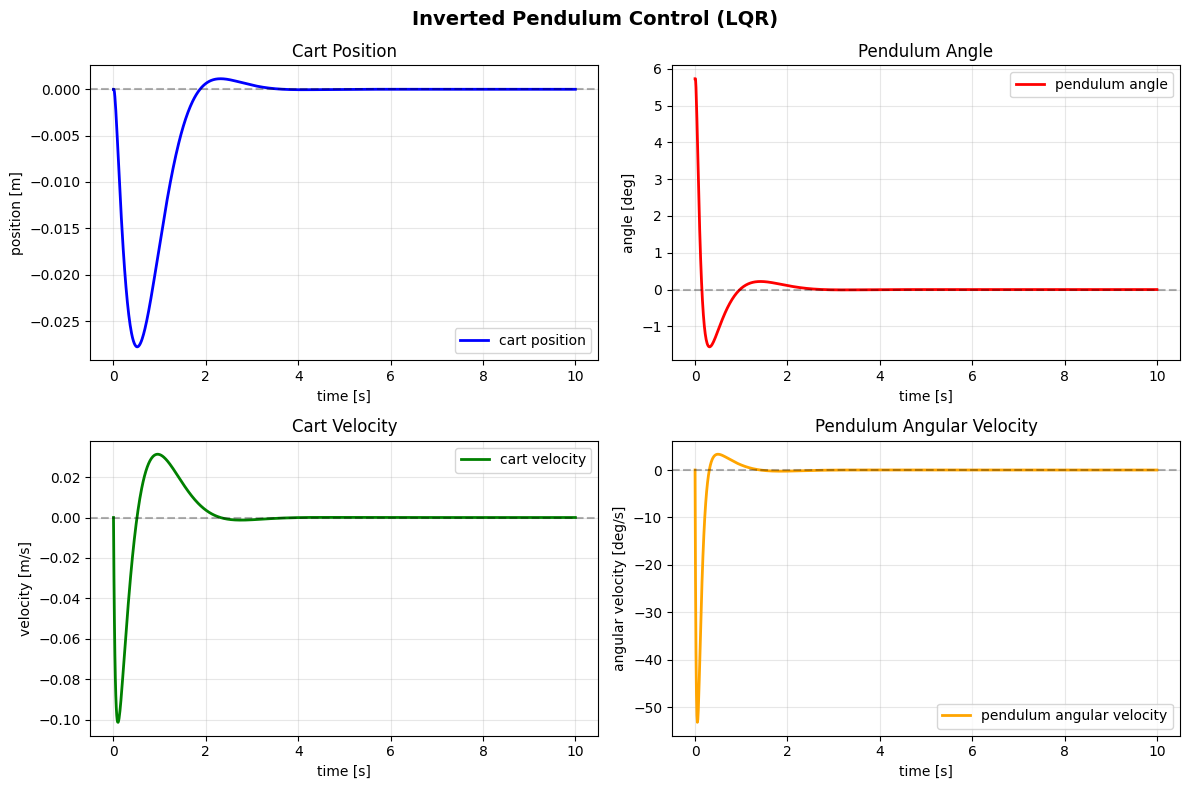

In [14]:
# ========== プロット ==========
# print("\n【グラフを生成中...】")
%matplotlib inline

# matplotlib_backend = plt.get_backend()
# if 'Agg' not in matplotlib_backend:
#    import matplotlib
#    matplotlib.use('Agg')

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle('Inverted Pendulum Control (LQR)', fontsize=14, fontweight='bold')

# プロット1: カート位置
ax = axes[0, 0]
ax.plot(t, x_lqr[:, 0], 'b-', linewidth=2, label='cart position')
ax.axhline(y=0, color='k', linestyle='--', alpha=0.3)
ax.set_xlabel('time [s]')
ax.set_ylabel('position [m]')
ax.set_title('Cart Position')
ax.grid(True, alpha=0.3)
ax.legend()

# プロット2: 振り子角度
ax = axes[0, 1]
ax.plot(t, np.degrees(x_lqr[:, 2]), 'r-', linewidth=2, label='pendulum angle')
ax.axhline(y=0, color='k', linestyle='--', alpha=0.3)
ax.set_xlabel('time [s]')
ax.set_ylabel('angle [deg]')
ax.set_title('Pendulum Angle')
ax.grid(True, alpha=0.3)
ax.legend()

# プロット3: カート速度
ax = axes[1, 0]
ax.plot(t, x_lqr[:, 1], 'g-', linewidth=2, label='cart velocity')
ax.axhline(y=0, color='k', linestyle='--', alpha=0.3)
ax.set_xlabel('time [s]')
ax.set_ylabel('velocity [m/s]')
ax.set_title('Cart Velocity')
ax.grid(True, alpha=0.3)
ax.legend()

# プロット4: 振り子角速度
ax = axes[1, 1]
ax.plot(t, np.degrees(x_lqr[:, 3]), 'orange', linewidth=2, label='pendulum angular velocity')
ax.axhline(y=0, color='k', linestyle='--', alpha=0.3)
ax.set_xlabel('time [s]')
ax.set_ylabel('angular velocity [deg/s]')
ax.set_title('Pendulum Angular Velocity')
ax.grid(True, alpha=0.3)
ax.legend()

plt.tight_layout()
# plt.savefig('inverted_pendulum_control.png', dpi=100, bbox_inches='tight')
# print("✓ グラフを保存しました: inverted_pendulum_control.png")


#### 【python-control の主要機能】
  
  • ctrl.StateSpace(A, B, C, D) - 状態空間表現

  • ctrl.pole(sys) - システムの極を計算

  • ctrl.ctrb(A, B) - 可制御行列を計算

  • ctrl.place(A, B, poles) - 極配置法

  • ctrl.lqr(A, B, Q, R) - LQR設計

  • ctrl.step_response() - ステップ応答
  
  • ctrl.impulse_response() - インパルス応答
  
#### 【シミュレーション結果の解釈】
  
  • カート位置: 安定に収束
  • 振り子角度: ほぼ0に保持（倒立形をキープ）
  • 振り子角度が制御でき、カートも振り子も安定